# Testes de Hipóteses no conjunto de dados de casas de Ames

In [15]:
!git clone https://github.com/mariribeiro257/estat-exame-B.git

fatal: destination path 'estat-exame-B' already exists and is not an empty directory.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as st

houses = pd.read_csv('estat-exame-B/houses.csv', keep_default_na=False, na_values=['NA',''])
houses.head()

# Aqui, defini que apenas "NA" e '' serão considerados como valores nulos
# "None" não será considerado nulo pois, em todas colunas que aparece, tem significado

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
# Verificando versao do scipy
import scipy
print(scipy.__version__)

1.16.3


In [17]:
# Tratando dados ausentes

def print_null_info(df):
    """Função para imprimir um relatório de integridade dos dados ausentes no DataFrame."""
    num_nulls = df.isnull().sum()
    num_nulls = num_nulls[num_nulls > 0]

    if num_nulls.empty:
        print("Diagnóstico concluído: Não existem valores nulos no DataFrame.")
        return

    percent_nulls = (num_nulls / len(df)) * 100

    null_values_df = pd.DataFrame({
        'Variável': num_nulls.index,
        'Total Nulos (Absoluto)': num_nulls.values,
        'Proporção (%)': percent_nulls.values
    })

    null_values_df = null_values_df.sort_values(by='Total Nulos (Absoluto)', ascending=False).reset_index(drop=True)

    print("=== RELATÓRIO DE INTEGRIDADE: DADOS AUSENTES ===")
    print(null_values_df.to_string(index=False, formatters={'Proporção (%)': '{:,.2f}%'.format}))

# Variáveis Categóricas (NA com significado real)
meaningfull_NA_list = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
for column in meaningfull_NA_list:
    houses[column] = houses[column].fillna('None') # trocando NA por None

# Variável Numérica: Ano da Garagem -> Imputação pela Mediana + Variável Indicadora
houses['HasGarage'] = houses['GarageYrBlt'].notnull().astype(int)
garage_median = houses['GarageYrBlt'].median()
houses['GarageYrBlt'] = houses['GarageYrBlt'].fillna(garage_median)

# Variável Numérica: Frente do Lote -> Imputação pela Mediana
lotfrontage_median = houses['LotFrontage'].median()
houses['LotFrontage'] = houses['LotFrontage'].fillna(lotfrontage_median)

# Variável Numérica: MasVnrArea -> Imputação pela Mediana
masvnrarea_median = houses['MasVnrArea'].median()
houses['MasVnrArea'] = houses['MasVnrArea'].fillna(masvnrarea_median)

# Variáveis Categóricas: Electrical e MasVnrType -> Imputação pela Moda
electrical_mode = houses['Electrical'].mode()[0]
houses['Electrical'] = houses['Electrical'].fillna(electrical_mode)

masvnrtype_mode = houses['MasVnrType'].mode()[0]
houses['MasVnrType'] = houses['MasVnrType'].fillna(masvnrtype_mode)

# RELATÓRIO FINAL DE VERIFICAÇÃO
print(f"Mediana utilizada para imputação de LotFrontage: {lotfrontage_median:.2f}")
print(f"Mediana utilizada para imputação de MasVnrArea: {masvnrarea_median:.2f}")
print(f"Moda utilizada para imputação de Electrical: {electrical_mode}")
print(f"Moda utilizada para imputação de MasVnrType: {masvnrtype_mode}")
print("-" * 50)
print_null_info(houses)

Mediana utilizada para imputação de LotFrontage: 69.00
Mediana utilizada para imputação de MasVnrArea: 0.00
Moda utilizada para imputação de Electrical: SBrkr
Moda utilizada para imputação de MasVnrType: None
--------------------------------------------------
Diagnóstico concluído: Não existem valores nulos no DataFrame.


## 1. Variáveis ordinais: Testes não paramétricos
Testes não paramétricos para utilizar com variáveis ordinais: Mann-Whitney, Wilcoxon e Kruskal-Wallis

Dados ordinais: estabelecem ordens, mas as distâncias entre as categorias não é uniforme ou quantificável

Testes paramétricos: muitas vezes exigem variaveis contínuas, uma distribuição específica, ou trabalham com médias

### ``OverallQual``

Hipótese nula: ``OverallQual`` não influencia no preço das casas (``SalePrice``)

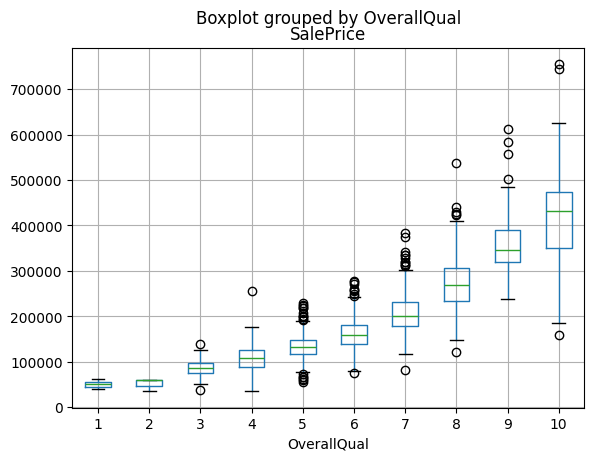

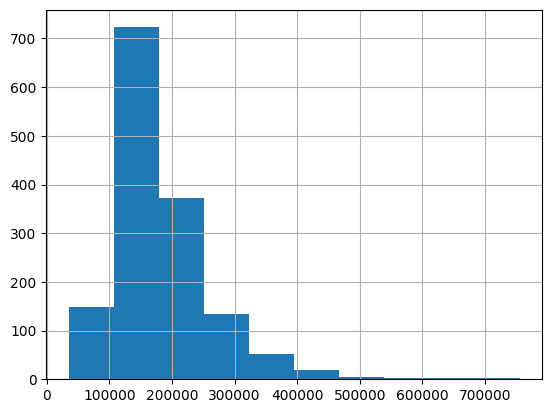

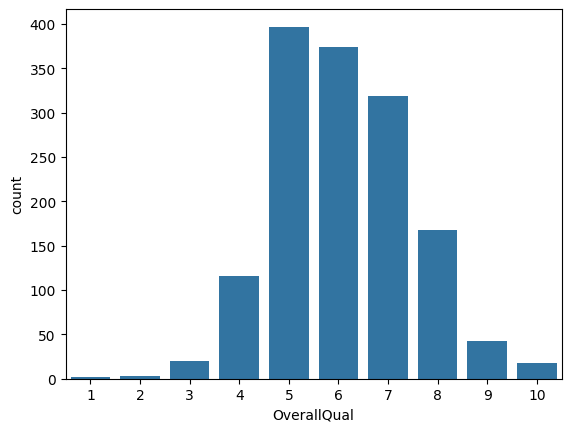

,count
OverallQual,
5,397
6,374
7,319
8,168
4,116
9,43
3,20
10,18
2,3


In [18]:
# Boxplot de SalePrice para variável categorica 'OverallQual'

houses.boxplot(column='SalePrice', by='OverallQual')
plt.show()
houses.SalePrice.hist()
plt.show()

# Countplot de OverallQual
sns.countplot(x='OverallQual', data=houses)
plt.show()
# Usando count para verificar a quantidade de amostras em cada grupo
houses.OverallQual.value_counts()

Para aplicar o teste ANOVA, temos que cumprir as suas premissas:

1. Distribuição normal: Os dados de cada grupo devem seguir uma distribuição normal.
2. Independência das observações
3. Homogeneidade das variâncias: As variações dentro de cada grupo devem ser aproximadamente iguais.

ShapiroResult(statistic=np.float64(0.9156138345664685), pvalue=np.float64(9.098749674477824e-28))


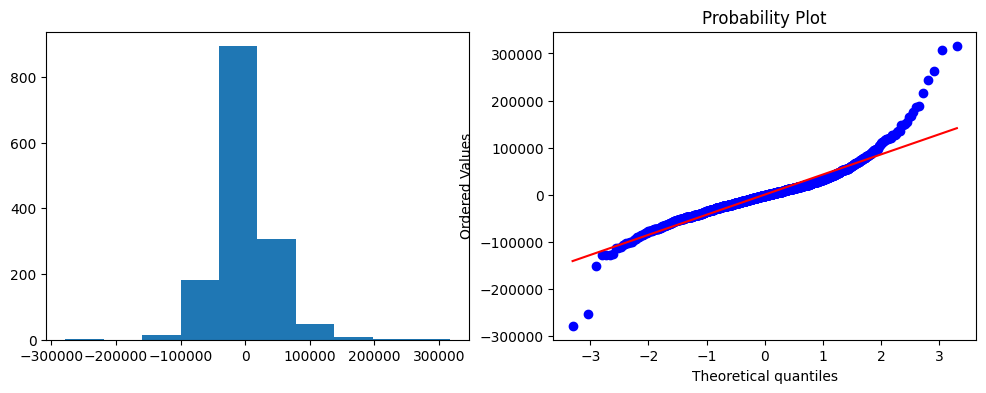

In [19]:
# Teste de Shapiro-Wilk para resíduos p/ verificar normalidade

def qqanalise(dados,distr="norm"):
  plt.figure(figsize=(12,4))
  plt.subplot(1,2,1)
  plt.hist(dados)
  plt.subplot(1,2,2)
  st.probplot(dados, dist=distr,plot=plt)
  plt.show()

# Calc residuos por grupo de OverallQual
residuos = []
for qual in sorted(houses.OverallQual.unique()):
    grupo = houses[houses.OverallQual == qual]
    residuos.extend(grupo.SalePrice - grupo.SalePrice.mean())

print(st.shapiro(residuos))
qqanalise(residuos)

ShapiroResult(statistic=np.float64(0.9821702505420192), pvalue=np.float64(1.820426431576732e-12))


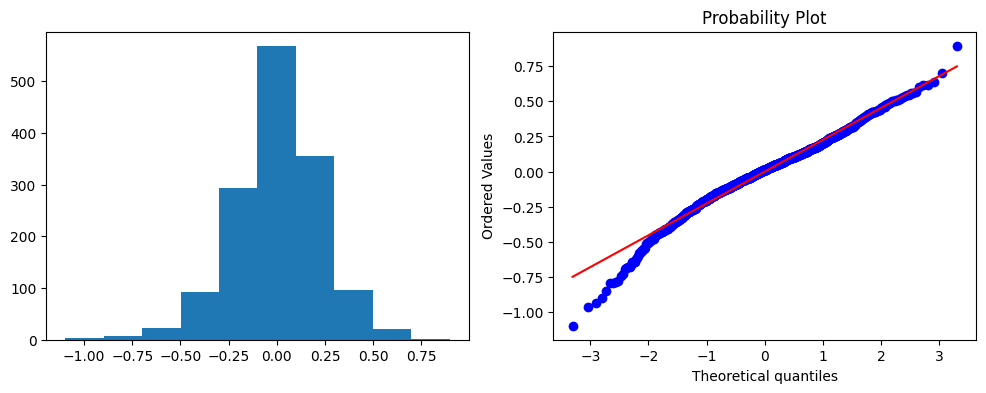

In [20]:
# Aplicando transformação logarítmica
houses['LogSalePrice'] = np.log(houses['SalePrice'])
residuos_log = []
for qual in sorted(houses.OverallQual.unique()):
    grupo = houses[houses.OverallQual == qual]
    residuos_log.extend(grupo.LogSalePrice - grupo.LogSalePrice.mean())
print(st.shapiro(residuos_log))
print(st.ander)
qqanalise(residuos_log)

Análise do resultado do teste de shapiro-wilk: como $\mathrm{p-valor} < 0.05$, a hipótese de que os resíduos de SalePrice para os grupos de OverallCond seguem uma distribuição normal pode ser descartada, mesmo com a transformação logarítmica

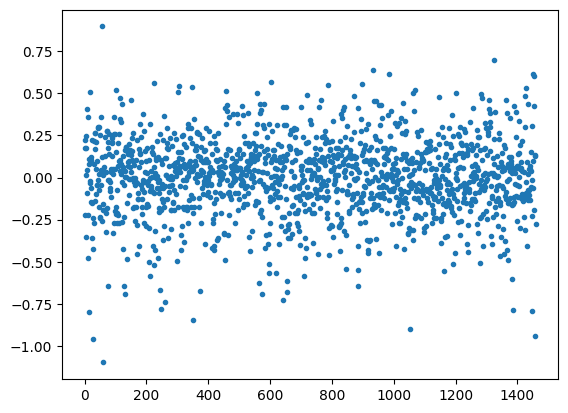

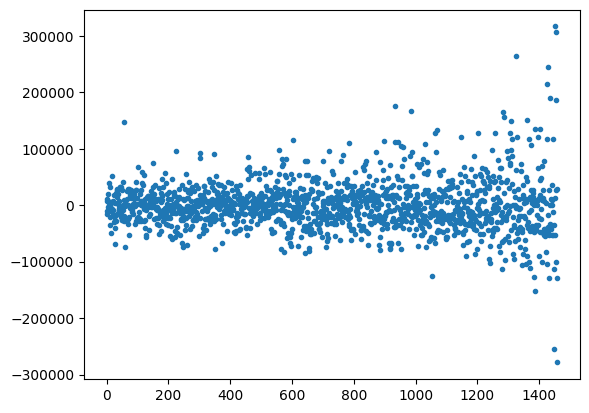

In [21]:
# Independencia das amostras

plt.plot(residuos_log, ".")
plt.show()

plt.plot(residuos, ".")

LeveneResult(statistic=np.float64(2.640511286598236), pvalue=np.float64(0.0049285025509718874))
OverallQual 1: Variância = 0.09664577341052265
OverallQual 2: Variância = 0.09368635217633747
OverallQual 3: Variância = 0.09407484016432399
OverallQual 4: Variância = 0.07856543374265708
OverallQual 5: Variância = 0.0445216935701087
OverallQual 6: Variância = 0.05284828180200772
OverallQual 7: Variância = 0.044478048709815726
OverallQual 8: Variância = 0.05350562456332808
OverallQual 9: Variância = 0.04142092138138357
OverallQual 10: Variância = 0.16277923068100297


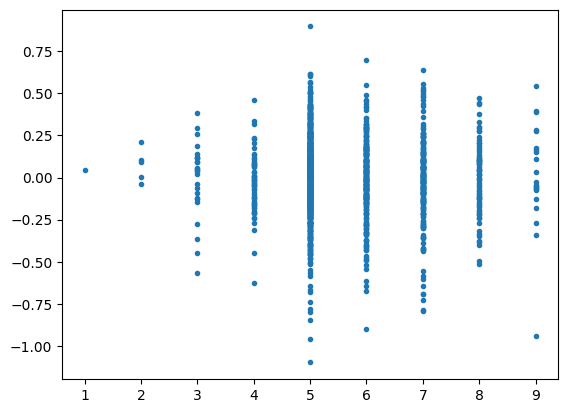

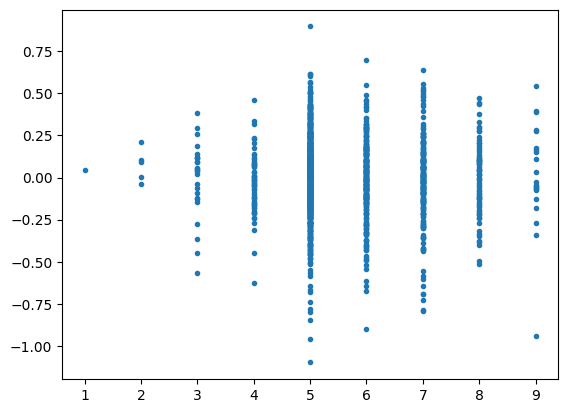

In [22]:
# Testando igualdade de variâncias entre os grupos
# Teste de Levene -> H0: variâncias iguais entre os grupos

print(st.levene(*[houses[houses.OverallQual == qual].LogSalePrice for qual in sorted(houses.OverallQual.unique())]))

for qual in sorted(houses.OverallQual.unique()):
    grupo = houses[houses.OverallQual == qual]
    print(f"OverallQual {qual}: Variância = {grupo.LogSalePrice.var()}")

# plotando residuos por grupo de OverallQual
plt.plot(houses.OverallCond, residuos_log, ".")
plt.show()
plt.plot(houses.OverallCond, residuos_log, ".")
plt.show()

Deu tudo errado.

### ``HasGarage``
H0: média de ``SalePrice`` é igual para casas com e sem garagem

Ha: média de ``SalePrice`` é diferente para casas com e sem garagem


ShapiroResult(statistic=np.float64(0.9909740257240115), pvalue=np.float64(8.067367471452798e-08))
AndersonResult(statistic=np.float64(3.9993252191416104), critical_values=array([0.574, 0.654, 0.785, 0.916, 1.089]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(-5.146568103193876e-16), scale=np.float64(0.378041035807216))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


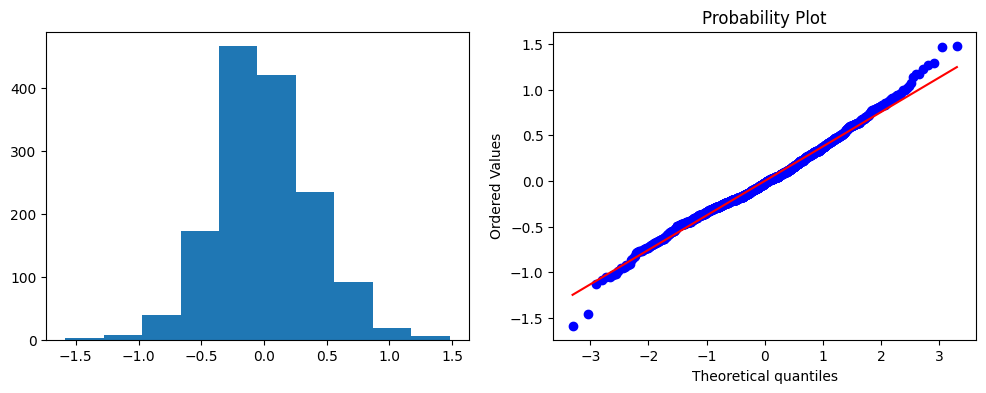

In [23]:
# Análise dos resíduos por variável categórica HasGarage

residuos_garage = []
for has_garage in sorted(houses.HasGarage.unique()):
    grupo = houses[houses.HasGarage == has_garage]
    residuos_garage.extend(grupo.LogSalePrice - grupo.LogSalePrice.mean())

print(st.shapiro(residuos_garage))
print(st.anderson(residuos_garage, dist='norm'))
qqanalise(residuos_garage)


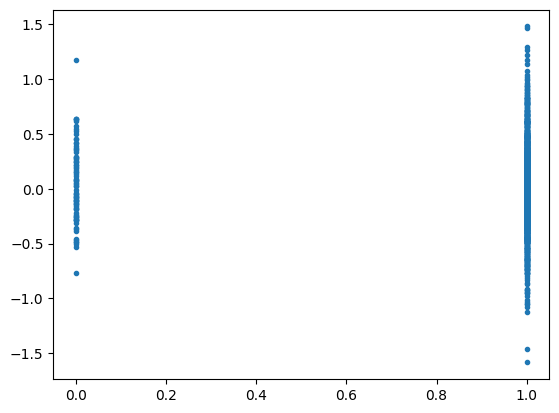

LeveneResult(statistic=np.float64(1.8722503299290216), pvalue=np.float64(0.17142838232743676))
Variância para HasGarage=0: 0.1170
Variância para HasGarage=1: 0.1445


In [24]:
# Analisando homogeneidade de variâncias para variável categórica HasGarage

# Plotando residuos por grupo de HasGarage
plt.plot(houses.HasGarage, residuos_garage, ".")
plt.show()

# Teste de Levene -> H0: variâncias iguais entre os grupos
print(st.levene(*[houses[houses.HasGarage == has_garage].LogSalePrice for has_garage in sorted(houses.HasGarage.unique())]))
print(f"Variância para HasGarage=0: {houses[houses.HasGarage == 0].LogSalePrice.var():.4f}")
print(f"Variância para HasGarage=1: {houses[houses.HasGarage == 1].LogSalePrice.var():.4f}")

Análise do teste de Levene: como p-valor é maior que 0.05, não se pode descartar a possibilidade das variâncias entre os grupos serem iguais

### ``MoSold``: Teste Qui-Quadrado de Aderência (Goodness-of-fit)
Verificar se a proporção de casas vendidas nos diferentes meses do ano em Ames segue uma distribuição uniforme (ou seja, se as vendas ocorrem em proporções exatamente iguais em todos os 12 meses).

### ``Neighborhood`` e ``OverallQual``: Teste Qui-Quadrado de Independência
Verificar se existe relação entre o "Bairro" e a "Qualidade Geral" nas casas de Ames.

Para utilizar o Teste Qui-Quadrado de Independência, devemos seguir as seguintes premissas:
1. Dados Categóricos: as variáveis analisadas são categóricas
2. Independência das observações: não pode haver medidas repetidas do mesmo sujeito. Assume-se independência nesse caso.
3. Amostragem aleatória
4. Frequência esperada mínima: Pelo menos 80% das células da nossa tabela devem ter uma frequência esperada (calculada teoricamente) igual ou superior a 5

In [31]:
tab_freq = pd.crosstab(houses.Neighborhood, houses.OverallQual)
stat_chi2, pvalor, graus_liberdade, freq_esperadas = st.chi2_contingency(tab_freq)

print(f"Estatística Qui-Quadrado: {stat_chi2:.4f}")
print(f"p-valor: {pvalor}")
print(f"Graus de Liberdade: {graus_liberdade}")

# verificando se frequencia esperada é maior que 5 para todas as células
for i in range(tab_freq.shape[0]):
    for j in range(tab_freq.shape[1]):
        if freq_esperadas[i, j] < 5:
          print(f"Frequência esperada na célula ({i}, {j}) é menor que 5.")

Estatística Qui-Quadrado: 1561.8155
p-valor: 2.185056661050645e-202
Graus de Liberdade: 216
Frequência esperada na célula (0, 0) é menor que 5.
Frequência esperada na célula (0, 1) é menor que 5.
Frequência esperada na célula (0, 2) é menor que 5.
Frequência esperada na célula (0, 3) é menor que 5.
Frequência esperada na célula (0, 4) é menor que 5.
Frequência esperada na célula (0, 5) é menor que 5.
Frequência esperada na célula (0, 6) é menor que 5.
Frequência esperada na célula (0, 7) é menor que 5.
Frequência esperada na célula (0, 8) é menor que 5.
Frequência esperada na célula (0, 9) é menor que 5.
Frequência esperada na célula (1, 0) é menor que 5.
Frequência esperada na célula (1, 1) é menor que 5.
Frequência esperada na célula (1, 2) é menor que 5.
Frequência esperada na célula (1, 3) é menor que 5.
Frequência esperada na célula (1, 4) é menor que 5.
Frequência esperada na célula (1, 5) é menor que 5.
Frequência esperada na célula (1, 6) é menor que 5.
Frequência esperada na c